# SHARC trajectory dihedral–bond-length plots

Trajectory-coordinate visualisations for azobenzene structure 0006. The setup cells reproduce the trajectory eligibility classification so that the plots can run independently.

In [1]:
from pathlib import Path

# Run from either the repository root or sharc/.
SEARCH_ROOT = Path("sharc") if Path("sharc").is_dir() else Path(".")
TRAJ_GLOB = "structure_0006/traj-allmols/**/TRAJ_*"

# 1-based C-N=N-C atom indices for azobenzene.
DIHEDRAL_ATOMS = (4, 5, 6, 7)
CIS_TRANS_THRESHOLD_DEG = 90.0
GROUND_MCH_STATE = 1
NN_BOND_MIN_ANGSTROM = 0.9
NN_BOND_EXCLUSION_ANGSTROM = 3.0

print(f"Searching: {SEARCH_ROOT.resolve()}")
print(f"Dihedral atoms: {DIHEDRAL_ATOMS}; ground MCH state: {GROUND_MCH_STATE}")

Searching: /home/lim_yt/X-MACE-sampling/sharc
Dihedral atoms: (4, 5, 6, 7); ground MCH state: 1


In [2]:
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def parse_xyz_lines(lines, source):
    """Return all conventional XYZ frames as (symbols, coordinates)."""
    frames, pos = [], 0
    while pos < len(lines):
        while pos < len(lines) and not lines[pos].strip():
            pos += 1
        if pos == len(lines):
            break
        try:
            natoms = int(lines[pos].strip())
        except ValueError as error:
            raise ValueError(f"{source}: expected atom count at line {pos + 1}") from error
        if natoms <= 0 or pos + natoms + 1 >= len(lines):
            raise ValueError(f"{source}: incomplete or invalid XYZ frame")
        symbols, xyz = [], []
        for line_number, line in enumerate(lines[pos + 2 : pos + 2 + natoms], pos + 3):
            fields = line.split()
            if len(fields) < 4:
                raise ValueError(f"{source}: malformed atom record at line {line_number}")
            try:
                xyz.append([float(value) for value in fields[1:4]])
            except ValueError as error:
                raise ValueError(f"{source}: non-numeric coordinate at line {line_number}") from error
            symbols.append(fields[0])
        frames.append((symbols, np.asarray(xyz, dtype=float)))
        pos += natoms + 2
    if not frames:
        raise ValueError(f"{source}: no XYZ frames")
    return frames


def signed_dihedral_deg(coordinates, atom_indices):
    indices = np.asarray(atom_indices, dtype=int) - 1
    if len(indices) != 4 or np.any(indices < 0) or np.any(indices >= len(coordinates)):
        raise ValueError(f"invalid atom indices {tuple(atom_indices)} for {len(coordinates)} atoms")
    p0, p1, p2, p3 = coordinates[indices]
    b0, b1, b2 = -(p1 - p0), p2 - p1, p3 - p2
    b1_norm = np.linalg.norm(b1)
    if b1_norm == 0:
        raise ValueError("middle dihedral bond has zero length")
    b1 /= b1_norm
    v, w = b0 - np.dot(b0, b1) * b1, b2 - np.dot(b2, b1) * b1
    if np.linalg.norm(v) == 0 or np.linalg.norm(w) == 0:
        raise ValueError("dihedral is undefined for collinear atoms")
    angle = math.degrees(math.atan2(np.dot(np.cross(b1, v), w), np.dot(v, w)))
    return ((angle + 180.0) % 360.0) - 180.0


def bond_length_angstrom(coordinates, atom_indices):
    """Return a 1-based atom-pair distance in Å."""
    indices = np.asarray(atom_indices, dtype=int) - 1
    if len(indices) != 2 or np.any(indices < 0) or np.any(indices >= len(coordinates)):
        raise ValueError(f"invalid atom indices {tuple(atom_indices)} for {len(coordinates)} atoms")
    return float(np.linalg.norm(coordinates[indices[0]] - coordinates[indices[1]]))


def frame_times_fs(lines, source):
    """Extract the SHARC time (fs) from each XYZ frame comment."""
    times, pos = [], 0
    while pos < len(lines):
        while pos < len(lines) and not lines[pos].strip():
            pos += 1
        if pos == len(lines):
            break
        try:
            natoms = int(lines[pos].strip())
        except ValueError as error:
            raise ValueError(f"{source}: expected atom count at line {pos + 1}") from error
        if pos + natoms + 1 >= len(lines):
            raise ValueError(f"{source}: incomplete or invalid XYZ frame")
        match = re.search(r"\bt=\s*([-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?)", lines[pos + 1])
        if not match:
            raise ValueError(f"{source}: missing time in frame comment at line {pos + 2}")
        times.append(float(match.group(1)))
        pos += natoms + 2
    return np.asarray(times, dtype=float)


def classify_dihedral(angle):
    return "cis" if abs(angle) <= CIS_TRANS_THRESHOLD_DEG else "trans"


def final_mch_state(lis_path):
    """Read the final SHARC output.lis data row: Step Time diag_state MCH_state ..."""
    rows = [line.split() for line in lis_path.read_text(encoding="utf-8").splitlines()
            if line.strip() and not line.lstrip().startswith("#")]
    if not rows or len(rows[-1]) < 4:
        raise ValueError(f"{lis_path}: no valid output.lis data row")
    try:
        return int(rows[-1][3])
    except ValueError as error:
        raise ValueError(f"{lis_path}: invalid final MCH state") from error


def mch_states(lis_path):
    """Read the MCH state for every SHARC output.lis time step."""
    rows = [line.split() for line in lis_path.read_text(encoding="utf-8").splitlines()
            if line.strip() and not line.lstrip().startswith("#")]
    if not rows or any(len(row) < 4 for row in rows):
        raise ValueError(f"{lis_path}: no valid output.lis data rows")
    try:
        return np.asarray([int(row[3]) for row in rows], dtype=int)
    except ValueError as error:
        raise ValueError(f"{lis_path}: invalid MCH state") from error


def outcome(initial, final, final_state):
    if final_state != GROUND_MCH_STATE:
        return "excluded_final_excited"
    return "reactive" if initial != final else "nonreactive"


def metadata(path):
    parts = path.parts
    pick = lambda prefix: next((part for part in parts if part.startswith(prefix)), "unknown")
    return pick("structure_"), pick("Singlet_"), pick("TRAJ_")

In [3]:
records = []
trajectory_dirs = sorted(path for path in SEARCH_ROOT.glob(TRAJ_GLOB) if path.is_dir())
if not trajectory_dirs:
    warnings.warn(f"No trajectory folders found under {SEARCH_ROOT}/{TRAJ_GLOB}")

for trajectory_dir in trajectory_dirs:
    xyz_path, lis_path = trajectory_dir / "output.xyz", trajectory_dir / "output.lis"
    structure, singlet, trajectory = metadata(trajectory_dir)
    record = {"structure": structure, "singlet": singlet, "trajectory": trajectory,
              "initial_dihedral_deg": np.nan, "initial_label": None,
              "final_dihedral_deg": np.nan, "final_label": None,
              "min_nn_bond_length_angstrom": np.nan,
              "max_nn_bond_length_angstrom": np.nan,
              "final_mch_state": pd.NA, "outcome": "skipped_invalid_output",
              "output_xyz": str(xyz_path), "reason": None}
    try:
        if not xyz_path.is_file() or xyz_path.stat().st_size == 0:
            raise ValueError("missing or empty output.xyz")
        if not lis_path.is_file() or lis_path.stat().st_size == 0:
            raise ValueError("missing or empty output.lis")
        frames = parse_xyz_lines(xyz_path.read_text(encoding="utf-8").splitlines(), str(xyz_path))
        nn_bond_lengths = [bond_length_angstrom(coordinates, DIHEDRAL_ATOMS[1:3]) for _, coordinates in frames]
        min_nn_bond_length = min(nn_bond_lengths)
        max_nn_bond_length = max(nn_bond_lengths)
        initial_angle = signed_dihedral_deg(frames[0][1], DIHEDRAL_ATOMS)
        final_angle = signed_dihedral_deg(frames[-1][1], DIHEDRAL_ATOMS)
        final_state = final_mch_state(lis_path)
        record.update({"initial_dihedral_deg": initial_angle, "initial_label": classify_dihedral(initial_angle),
                       "final_dihedral_deg": final_angle, "final_label": classify_dihedral(final_angle),
                       "min_nn_bond_length_angstrom": min_nn_bond_length,
                       "max_nn_bond_length_angstrom": max_nn_bond_length, "final_mch_state": final_state})
        if min_nn_bond_length < NN_BOND_MIN_ANGSTROM or max_nn_bond_length > NN_BOND_EXCLUSION_ANGSTROM:
            record["outcome"] = "excluded_nn_bond_length"
        else:
            record["outcome"] = outcome(record["initial_label"], record["final_label"], final_state)
    except (OSError, UnicodeDecodeError, ValueError) as error:
        record["reason"] = str(error)
        warnings.warn(f"Skipped {trajectory_dir}: {error}")
    records.append(record)

results = pd.DataFrame(records)
for column in ("initial_dihedral_deg", "final_dihedral_deg"):
    if column in results:
        results[column] = results[column].round(3)
results

,structure,singlet,trajectory,initial_dihedral_deg,initial_label,final_dihedral_deg,final_label,min_nn_bond_length_angstrom,max_nn_bond_length_angstrom,final_mch_state,outcome,output_xyz,reason
0,structure_0006,Singlet_1,TRAJ_00001,173.213,trans,151.032,trans,1.264827,1.550475,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
1,structure_0006,Singlet_1,TRAJ_00002,173.453,trans,177.190,trans,1.067240,1.535227,1,nonreactive,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
2,structure_0006,Singlet_1,TRAJ_00003,172.012,trans,171.061,trans,1.288529,1.500393,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
3,structure_0006,Singlet_1,TRAJ_00004,169.124,trans,164.667,trans,1.221838,1.565316,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
4,structure_0006,Singlet_1,TRAJ_00005,167.627,trans,178.952,trans,1.253021,1.533092,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,structure_0006,Singlet_1,TRAJ_00096,-171.570,trans,-177.485,trans,1.267475,1.551494,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
96,structure_0006,Singlet_1,TRAJ_00097,-169.612,trans,-28.059,cis,0.565581,39915.100176,1,excluded_nn_bond_length,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
97,structure_0006,Singlet_1,TRAJ_00098,-170.529,trans,177.446,trans,1.243930,1.543093,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
98,structure_0006,Singlet_1,TRAJ_00099,-173.994,trans,-158.385,trans,1.183617,1.554758,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None


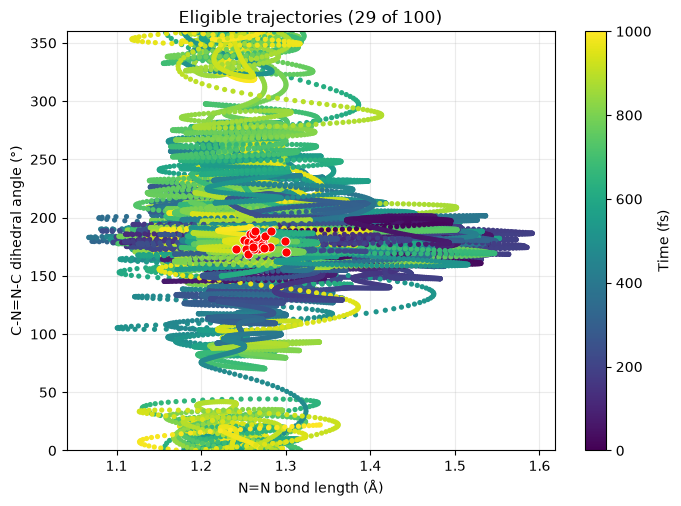

In [4]:
# Plot eligible trajectories only. Replace this with a list of TRAJ_* names to select a subset.
TRAJECTORIES_TO_PLOT = [path.name for path in trajectory_dirs]
NN_BOND_ATOMS = DIHEDRAL_ATOMS[1:3]  # the two N atoms in the C-N=N-C dihedral

requested_dirs = [path for path in trajectory_dirs if path.name in TRAJECTORIES_TO_PLOT]
missing = sorted(set(TRAJECTORIES_TO_PLOT) - {path.name for path in requested_dirs})
if missing:
    raise FileNotFoundError(f"Trajectory folders not found: {', '.join(missing)}")
eligible_trajectory_names = set(results.loc[results["outcome"].isin(["reactive", "nonreactive"]), "trajectory"])
selected_dirs = [path for path in requested_dirs if path.name in eligible_trajectory_names]
if not selected_dirs:
    raise ValueError("None of the requested trajectories are eligible for the quantum-yield calculation")

trajectory_data = []
for trajectory_dir in selected_dirs:
    xyz_path = trajectory_dir / "output.xyz"
    lines = xyz_path.read_text(encoding="utf-8").splitlines()
    frames = parse_xyz_lines(lines, str(xyz_path))
    times_fs = frame_times_fs(lines, str(xyz_path))
    if len(frames) != len(times_fs):
        raise ValueError(f"{xyz_path}: frame/time count mismatch")
    nn_distance_angstrom = np.asarray([
        np.linalg.norm(coordinates[NN_BOND_ATOMS[0] - 1] - coordinates[NN_BOND_ATOMS[1] - 1])
        for _, coordinates in frames
    ])
    dihedral_deg = np.asarray([signed_dihedral_deg(coordinates, DIHEDRAL_ATOMS) % 360.0 for _, coordinates in frames])
    trajectory_data.append((trajectory_dir.name, times_fs, nn_distance_angstrom, dihedral_deg))

all_times = np.concatenate([times for _, times, _, _ in trajectory_data])
time_norm = plt.Normalize(all_times.min(), all_times.max())
cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize=(7, 5))
for name, times_fs, nn_distance_angstrom, dihedral_deg in trajectory_data:
    ax.scatter(nn_distance_angstrom, dihedral_deg, c=times_fs, cmap=cmap, norm=time_norm,
               s=14, edgecolors="none", zorder=2)
    ax.scatter(nn_distance_angstrom[0], dihedral_deg[0], color="red", s=42,
               edgecolors="white", linewidths=0.6, zorder=3)

colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=time_norm, cmap=cmap), ax=ax)
colorbar.set_label("Time (fs)")
ax.set(xlabel="N=N bond length (Å)", ylabel="C-N=N-C dihedral angle (°)", ylim=(0, 360))
ax.grid(alpha=0.25)
fig.tight_layout()
plt.title(f"Eligible trajectories ({len(selected_dirs)} of {len(trajectory_dirs)})")
plt.show()

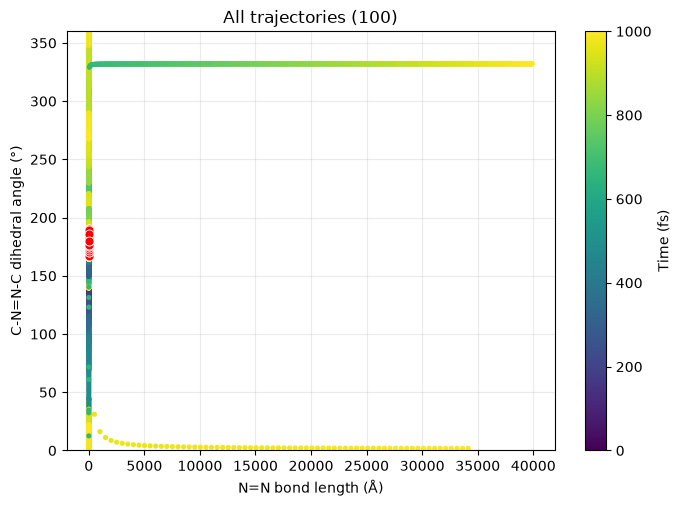

In [5]:
# Plot all trajectories. Replace this with a list of TRAJ_* names to select a subset.
TRAJECTORIES_TO_PLOT = [path.name for path in trajectory_dirs]
NN_BOND_ATOMS = DIHEDRAL_ATOMS[1:3]  # the two N atoms in the C-N=N-C dihedral

requested_dirs = [path for path in trajectory_dirs if path.name in TRAJECTORIES_TO_PLOT]
missing = sorted(set(TRAJECTORIES_TO_PLOT) - {path.name for path in requested_dirs})
if missing:
    raise FileNotFoundError(f"Trajectory folders not found: {', '.join(missing)}")
selected_dirs = requested_dirs  # Deliberately include eligible and excluded trajectories.

trajectory_data = []
for trajectory_dir in selected_dirs:
    xyz_path = trajectory_dir / "output.xyz"
    lines = xyz_path.read_text(encoding="utf-8").splitlines()
    frames = parse_xyz_lines(lines, str(xyz_path))
    times_fs = frame_times_fs(lines, str(xyz_path))
    if len(frames) != len(times_fs):
        raise ValueError(f"{xyz_path}: frame/time count mismatch")
    nn_distance_angstrom = np.asarray([
        np.linalg.norm(coordinates[NN_BOND_ATOMS[0] - 1] - coordinates[NN_BOND_ATOMS[1] - 1])
        for _, coordinates in frames
    ])
    dihedral_deg = np.asarray([signed_dihedral_deg(coordinates, DIHEDRAL_ATOMS) % 360.0 for _, coordinates in frames])
    trajectory_data.append((trajectory_dir.name, times_fs, nn_distance_angstrom, dihedral_deg))

all_times = np.concatenate([times for _, times, _, _ in trajectory_data])
time_norm = plt.Normalize(all_times.min(), all_times.max())
cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize=(7, 5))
for name, times_fs, nn_distance_angstrom, dihedral_deg in trajectory_data:
    ax.scatter(nn_distance_angstrom, dihedral_deg, c=times_fs, cmap=cmap, norm=time_norm,
               s=14, edgecolors="none", zorder=2)
    ax.scatter(nn_distance_angstrom[0], dihedral_deg[0], color="red", s=42,
               edgecolors="white", linewidths=0.6, zorder=3)

colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=time_norm, cmap=cmap), ax=ax)
colorbar.set_label("Time (fs)")
ax.set(xlabel="N=N bond length (Å)", ylabel="C-N=N-C dihedral angle (°)", ylim=(0, 360))
ax.grid(alpha=0.25)
fig.tight_layout()
plt.title(f"All trajectories ({len(trajectory_dirs)})")
plt.show()

In [ ]:
# Plot all trajectories except those excluded by the N=N bond-length rule.
nn_excluded_trajectory_names = set(results.loc[results["outcome"] == "excluded_nn_bond_length", "trajectory"])
non_broken_dirs = [path for path in trajectory_dirs if path.name not in nn_excluded_trajectory_names]
non_broken_trajectory_data = []
for trajectory_dir in non_broken_dirs:
    xyz_path = trajectory_dir / "output.xyz"
    lines = xyz_path.read_text(encoding="utf-8").splitlines()
    frames = parse_xyz_lines(lines, str(xyz_path))
    times_fs = frame_times_fs(lines, str(xyz_path))
    if len(frames) != len(times_fs):
        raise ValueError(f"{xyz_path}: frame/time count mismatch")
    nn_distance_angstrom = np.asarray([
        bond_length_angstrom(coordinates, DIHEDRAL_ATOMS[1:3]) for _, coordinates in frames
    ])
    dihedral_deg = np.asarray([signed_dihedral_deg(coordinates, DIHEDRAL_ATOMS) % 360.0 for _, coordinates in frames])
    non_broken_trajectory_data.append((trajectory_dir.name, times_fs, nn_distance_angstrom, dihedral_deg))

all_times = np.concatenate([times for _, times, _, _ in non_broken_trajectory_data])
time_norm = plt.Normalize(all_times.min(), all_times.max())
cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize=(7, 5))
for _, times_fs, nn_distance_angstrom, dihedral_deg in non_broken_trajectory_data:
    ax.scatter(nn_distance_angstrom, dihedral_deg, c=times_fs, cmap=cmap, norm=time_norm,
               s=10, edgecolors="none", zorder=2)
    ax.scatter(nn_distance_angstrom[0], dihedral_deg[0], color="red", s=32,
               edgecolors="white", linewidths=0.5, zorder=3)

colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=time_norm, cmap=cmap), ax=ax)
colorbar.set_label("Time (fs)")
ax.set(xlabel="N=N bond length (Å)", ylabel="C-N=N-C dihedral angle (°)", ylim=(0, 360))
ax.set_title(f"All trajectories except N=N bond-length exclusions ({len(non_broken_trajectory_data)} of {len(trajectory_dirs)})")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [ ]:
# Eligible trajectories, with categorical colors denoting the MCH state at each frame.
eligible_trajectory_names = set(results.loc[results["outcome"].isin(["reactive", "nonreactive"]), "trajectory"])
eligible_dirs = [path for path in trajectory_dirs if path.name in eligible_trajectory_names]
eligible_mch_data = []
for trajectory_dir in eligible_dirs:
    xyz_path, lis_path = trajectory_dir / "output.xyz", trajectory_dir / "output.lis"
    lines = xyz_path.read_text(encoding="utf-8").splitlines()
    frames = parse_xyz_lines(lines, str(xyz_path))
    states = mch_states(lis_path)
    times_fs = frame_times_fs(lines, str(xyz_path))
    if len(frames) != len(states) or len(frames) != len(times_fs):
        raise ValueError(f"{trajectory_dir}: XYZ/MCH-state frame count mismatch")
    nn_distance_angstrom = np.asarray([
        bond_length_angstrom(coordinates, DIHEDRAL_ATOMS[1:3]) for _, coordinates in frames
    ])
    dihedral_deg = np.asarray([signed_dihedral_deg(coordinates, DIHEDRAL_ATOMS) % 360.0 for _, coordinates in frames])
    eligible_mch_data.append((states, times_fs, nn_distance_angstrom, dihedral_deg))

states_present = sorted({int(state) for states, _, _, _ in eligible_mch_data for state in np.unique(states)})
state_cmaps = {state: plt.get_cmap(cmap_name) for state, cmap_name in zip(states_present, ["Blues", "Reds"])}
all_times = np.concatenate([times for _, times, _, _ in eligible_mch_data])
time_norm = plt.Normalize(all_times.min(), all_times.max())
fig, ax = plt.subplots(figsize=(7, 5))
for state in states_present:
    is_first_collection = True
    for states, times_fs, nn_distance_angstrom, dihedral_deg in eligible_mch_data:
        mask = states == state
        if mask.any():
            ax.scatter(nn_distance_angstrom[mask], dihedral_deg[mask], c=times_fs[mask], cmap=state_cmaps[state],
                       norm=time_norm, s=10, edgecolors="none",
                       label=f"S{state-1}" if is_first_collection else None)
            is_first_collection = False

for _, _, nn_distance_angstrom, dihedral_deg in eligible_mch_data:
    ax.scatter(nn_distance_angstrom[0], dihedral_deg[0], facecolors="none", edgecolors="red",
               s=34, linewidths=0.7, zorder=3)

for state in states_present:
    colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=time_norm, cmap=state_cmaps[state]), ax=ax, pad=0.02)
    colorbar.set_label(f"Time (fs), S{state-1}")

ax.set(xlabel="N=N bond length (Å)", ylabel="C-N=N-C dihedral angle (°)", ylim=(0, 360))
ax.set_title(f"Eligible trajectories ({len(eligible_mch_data)} of {len(trajectory_dirs)})\ncoloured by electronic state")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [ ]:
# Change this folder name to inspect an individual trajectory.
TRAJECTORY_TO_PLOT = "TRAJ_00026"

matching_dirs = [path for path in trajectory_dirs if path.name == TRAJECTORY_TO_PLOT]
if len(matching_dirs) != 1:
    raise FileNotFoundError(f"Expected one trajectory folder named {TRAJECTORY_TO_PLOT}, found {len(matching_dirs)}")

trajectory_dir = matching_dirs[0]
xyz_path, lis_path = trajectory_dir / "output.xyz", trajectory_dir / "output.lis"
lines = xyz_path.read_text(encoding="utf-8").splitlines()
frames = parse_xyz_lines(lines, str(xyz_path))
times_fs = frame_times_fs(lines, str(xyz_path))
states = mch_states(lis_path)
if len(frames) != len(times_fs) or len(frames) != len(states):
    raise ValueError(f"{trajectory_dir}: XYZ/time/MCH-state frame count mismatch")
nn_distance_angstrom = np.asarray([
    bond_length_angstrom(coordinates, DIHEDRAL_ATOMS[1:3]) for _, coordinates in frames
])
dihedral_deg = np.asarray([signed_dihedral_deg(coordinates, DIHEDRAL_ATOMS) % 360.0 for _, coordinates in frames])

states_present = sorted(np.unique(states))
state_cmaps = {1: plt.get_cmap("Blues"), 2: plt.get_cmap("Reds")}
time_norm = plt.Normalize(times_fs.min(), times_fs.max())
fig, ax = plt.subplots(figsize=(7, 5))
for state in states_present:
    if state not in state_cmaps:
        raise ValueError(f"No color scale configured for MCH state {state}")
    mask = states == state
    ax.scatter(nn_distance_angstrom[mask], dihedral_deg[mask], c=times_fs[mask], cmap=state_cmaps[state],
               norm=time_norm, s=18, edgecolors="none", label=f"S{state-1}")

ax.scatter(nn_distance_angstrom[0], dihedral_deg[0], facecolors="none", edgecolors="red",
           s=46, linewidths=0.8, zorder=3)
for state in states_present:
    colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=time_norm, cmap=state_cmaps[state]), ax=ax, pad=0.02)
    colorbar.set_label(f"Time (fs), S{state-1}")
ax.set(xlabel="N=N bond length (Å)", ylabel="C-N=N-C dihedral angle (°)", ylim=(0, 360))
ax.set_title(TRAJECTORY_TO_PLOT)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()